In [17]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/df2kdata/DF2K_valid_LR_bicubic/X3/0882x3.png
/kaggle/input/df2kdata/DF2K_valid_LR_bicubic/X3/0861x3.png
/kaggle/input/df2kdata/DF2K_valid_LR_bicubic/X3/0841x3.png
/kaggle/input/df2kdata/DF2K_valid_LR_bicubic/X3/0860x3.png
/kaggle/input/df2kdata/DF2K_valid_LR_bicubic/X3/0879x3.png
/kaggle/input/df2kdata/DF2K_valid_LR_bicubic/X3/0814x3.png
/kaggle/input/df2kdata/DF2K_valid_LR_bicubic/X3/0801x3.png
/kaggle/input/df2kdata/DF2K_valid_LR_bicubic/X3/0836x3.png
/kaggle/input/df2kdata/DF2K_valid_LR_bicubic/X3/0804x3.png
/kaggle/input/df2kdata/DF2K_valid_LR_bicubic/X3/0823x3.png
/kaggle/input/df2kdata/DF2K_valid_LR_bicubic/X3/0821x3.png
/kaggle/input/df2kdata/DF2K_valid_LR_bicubic/X3/0856x3.png
/kaggle/input/df2kdata/DF2K_valid_LR_bicubic/X3/0831x3.png
/kaggle/input/df2kdata/DF2K_valid_LR_bicubic/X3/0884x3.png
/kaggle/input/df2kdata/DF2K_valid_LR_bicubic/X3/0849x3.png
/kaggle/input/df2kdata/DF2K_valid_LR_bicubic/X3/0862x3.png
/kaggle/input/df2kdata/DF2K_valid_LR_bicubic/X3/0872x3.p

In [18]:
import os
import glob
import math
import random
import re
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

In [19]:
# ==========================================
# 1. CONFIGURATION
# ==========================================
class Config:
    # --- 1. Auto-Detect Dataset Paths ---
    print("🔍 Searching for dataset location...")
    found_paths = glob.glob("/kaggle/input/**/DF2K_train_HR", recursive=True)
    
    if not found_paths:
        raise RuntimeError("❌ ERROR: Could not find 'DF2K_train_HR'. Please check input!")
    
    HR_DIR = found_paths[0]
    DATASET_ROOT = os.path.dirname(HR_DIR)
    
    # Construct relative paths
    LR_DIR = os.path.join(DATASET_ROOT, "DF2K_train_LR_bicubic", "X4")
    VALID_HR_DIR = os.path.join(DATASET_ROOT, "DF2K_valid_HR")
    VALID_LR_DIR = os.path.join(DATASET_ROOT, "DF2K_valid_LR_bicubic", "X4")

    print(f"✅ Found HR Folder: {HR_DIR}")
    
    # --- 2. Training Settings ---
    IMG_SIZE = 128          
    BATCH_SIZE = 32         
    TIMESTEPS = 1000        
    EPOCHS = 100            
    LR = 1e-4               
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
    SAVE_DIR = "/kaggle/working/models"
    
    # --- 3. RESUME CONFIGURATION ---
    # Update this path to match your saved model file exactly!
    # If starting fresh, set this to: None
    RESUME_PATH = "/kaggle/working/models/sr_model_ep30.pth" 

os.makedirs(Config.SAVE_DIR, exist_ok=True)

🔍 Searching for dataset location...
✅ Found HR Folder: /kaggle/input/df2kdata/DF2K_train_HR


In [20]:
# ==========================================
# 2. DATASET (ROBUST)
# ==========================================
class DF2KDataset(Dataset):
    def __init__(self, hr_dir, lr_dir, crop_size=128):
        super().__init__()
        self.hr_paths = sorted(glob.glob(os.path.join(hr_dir, "*.png")))
        self.lr_dir = lr_dir
        self.crop_size = crop_size
        
        if len(self.hr_paths) == 0:
            raise ValueError(f"❌ ERROR: No images found in {hr_dir}")
            
        self.to_tensor = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(0.5, 0.5)
        ])

    def __len__(self):
        return len(self.hr_paths)

    def __getitem__(self, idx):
        hr_path = self.hr_paths[idx]
        hr_name = os.path.basename(hr_path)
        lr_name = hr_name.replace(".png", "x4.png") 
        lr_path = os.path.join(self.lr_dir, lr_name)
        
        try:
            hr_img = Image.open(hr_path).convert("RGB")
            lr_img = Image.open(lr_path).convert("RGB")
        except (FileNotFoundError, OSError):
            return self.__getitem__(random.randint(0, len(self.hr_paths)-1))

        # Handle Variable Sizes via Padding
        w_lr, h_lr = lr_img.size
        lr_crop_size = self.crop_size // 4 
        
        if w_lr < lr_crop_size or h_lr < lr_crop_size:
            pad_w = max(lr_crop_size - w_lr, 0)
            pad_h = max(lr_crop_size - h_lr, 0)
            lr_img = transforms.Pad((0, 0, pad_w, pad_h), fill=0)(lr_img)
            hr_img = transforms.Pad((0, 0, pad_w*4, pad_h*4), fill=0)(hr_img)
            w_lr, h_lr = lr_img.size 

        # Random Crop
        lr_x = random.randint(0, w_lr - lr_crop_size)
        lr_y = random.randint(0, h_lr - lr_crop_size)
        
        lr_patch = lr_img.crop((lr_x, lr_y, lr_x + lr_crop_size, lr_y + lr_crop_size))
        hr_patch = hr_img.crop((lr_x*4, lr_y*4, lr_x*4 + self.crop_size, lr_y*4 + self.crop_size))
        
        # Transform
        hr_tensor = self.to_tensor(hr_patch)
        lr_tensor = self.to_tensor(lr_patch)
        
        # Upscale LR for Conditioning
        lr_upscaled = F.interpolate(
            lr_tensor.unsqueeze(0), 
            size=(self.crop_size, self.crop_size), 
            mode='bicubic', align_corners=False
        ).squeeze(0)

        return hr_tensor, lr_upscaled

In [21]:
# ==========================================
# 3. U-NET MODEL
# ==========================================
class SinusoidalPositionEmbeddings(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, time):
        device = time.device
        half_dim = self.dim // 2
        embeddings = math.log(10000) / (half_dim - 1)
        embeddings = torch.exp(torch.arange(half_dim, device=device) * -embeddings)
        embeddings = time[:, None] * embeddings[None, :]
        embeddings = torch.cat((embeddings.sin(), embeddings.cos()), dim=-1)
        return embeddings

In [22]:
class Block(nn.Module):
    def __init__(self, in_ch, out_ch, time_emb_dim, up=False):
        super().__init__()
        self.time_mlp =  nn.Linear(time_emb_dim, out_ch)
        if up:
            self.conv1 = nn.Conv2d(2*in_ch, out_ch, 3, padding=1)
            self.transform = nn.ConvTranspose2d(out_ch, out_ch, 4, 2, 1)
        else:
            self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
            self.transform = nn.Conv2d(out_ch, out_ch, 4, 2, 1)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.bnorm1 = nn.BatchNorm2d(out_ch)
        self.bnorm2 = nn.BatchNorm2d(out_ch)
        self.relu  = nn.ReLU()

    def forward(self, x, t):
        h = self.bnorm1(self.relu(self.conv1(x)))
        time_emb = self.relu(self.time_mlp(t))
        time_emb = time_emb[(..., ) + (None, ) * 2]
        h = h + time_emb
        h = self.bnorm2(self.relu(self.conv2(h)))
        return self.transform(h)

In [23]:
class SimpleSRUNet(nn.Module):
    def __init__(self):
        super().__init__()
        image_channels = 3
        down_channels = (64, 128, 256, 512)
        up_channels = (512, 256, 128, 64)
        out_dim = image_channels 
        time_emb_dim = 32

        self.time_mlp = nn.Sequential(
            SinusoidalPositionEmbeddings(time_emb_dim),
            nn.Linear(time_emb_dim, time_emb_dim),
            nn.ReLU()
        )
        
        self.conv0 = nn.Conv2d(image_channels * 2, down_channels[0], 3, padding=1)
        self.downs = nn.ModuleList([Block(down_channels[i], down_channels[i+1], time_emb_dim) for i in range(len(down_channels)-1)])
        self.ups = nn.ModuleList([Block(up_channels[i], up_channels[i+1], time_emb_dim, up=True) for i in range(len(up_channels)-1)])
        self.output = nn.Conv2d(up_channels[-1], out_dim, 1)

    def forward(self, x, lr_imgs, t):
        t = self.time_mlp(t)
        x = torch.cat([x, lr_imgs], dim=1)
        x = self.conv0(x)
        residuals = []
        for down in self.downs:
            x = down(x, t)
            residuals.append(x)
        for up in self.ups:
            residual = residuals.pop()
            x = torch.cat((x, residual), dim=1)
            x = up(x, t)
        return self.output(x)

In [24]:
# ==========================================
# 4. TRAINING LOOP (FIXED RESUME LOGIC)
# ==========================================
def train_model():
    print("⏳ Loading Dataset...")
    dataset = DF2KDataset(Config.HR_DIR, Config.LR_DIR, crop_size=Config.IMG_SIZE)
    dataloader = DataLoader(dataset, batch_size=Config.BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
    
    model = SimpleSRUNet().to(Config.DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=Config.LR)
    mse = nn.MSELoss()
    
    # Diffusion Constants
    betas = torch.linspace(0.0001, 0.02, Config.TIMESTEPS).to(Config.DEVICE)
    alphas = 1. - betas
    alphas_cumprod = torch.cumprod(alphas, axis=0)
    sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod)
    sqrt_one_minus_alphas_cumprod = torch.sqrt(1. - alphas_cumprod)

    # --- 🟢 SMART RESUME LOGIC STARTS HERE ---
    start_epoch = 0
    if Config.RESUME_PATH and os.path.exists(Config.RESUME_PATH):
        print(f"🔄 Found checkpoint: {Config.RESUME_PATH}")
        print("📥 Loading model weights...")
        try:
            model.load_state_dict(torch.load(Config.RESUME_PATH))
            print("✅ Weights loaded successfully.")
            
            # Extract number from filename (e.g. "ep30")
            match = re.search(r"ep(\d+)", Config.RESUME_PATH)
            if match:
                start_epoch = int(match.group(1))
                print(f"⏩ Fast-forwarding training to Epoch {start_epoch + 1}")
            else:
                print("⚠️ Filename didn't have a number. Starting counter at 1.")
        except Exception as e:
            print(f"❌ Error loading checkpoint: {e}")
            print("⚠️ Starting from scratch.")
            start_epoch = 0
    else:
        if Config.RESUME_PATH:
            print(f"⚠️ Warning: RESUME_PATH was set to '{Config.RESUME_PATH}' but file not found.")
            print("⚠️ Starting from scratch.")

    print(f"🚀 Training range: Epoch {start_epoch + 1} -> {Config.EPOCHS}")
    
    # 🟢 Loop uses start_epoch!
    for epoch in range(start_epoch, Config.EPOCHS):
        model.train()
        pbar = tqdm(dataloader, desc=f"Epoch {epoch+1}/{Config.EPOCHS}")
        epoch_loss = 0
        
        for hr_imgs, lr_upscaled in pbar:
            hr_imgs = hr_imgs.to(Config.DEVICE)
            lr_upscaled = lr_upscaled.to(Config.DEVICE)
            
            t = torch.randint(0, Config.TIMESTEPS, (hr_imgs.shape[0],), device=Config.DEVICE).long()
            noise = torch.randn_like(hr_imgs)
            
            sqrt_alpha_hat = sqrt_alphas_cumprod[t][:, None, None, None]
            sqrt_one_minus_alpha_hat = sqrt_one_minus_alphas_cumprod[t][:, None, None, None]
            
            x_t = sqrt_alpha_hat * hr_imgs + sqrt_one_minus_alpha_hat * noise
            predicted_noise = model(x_t, lr_upscaled, t)
            
            loss = mse(noise, predicted_noise)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            pbar.set_postfix(loss=loss.item())

        # Save Checkpoint
        if (epoch + 1) % 5 == 0:
            save_path = f"{Config.SAVE_DIR}/sr_model_ep{epoch+1}.pth"
            torch.save(model.state_dict(), save_path)
            print(f"💾 Saved model: {save_path}")

    return model, betas, alphas, alphas_cumprod

In [25]:
# ==========================================
# 5. INFERENCE (TESTING)
# ==========================================
def run_inference(model, betas, alphas, alphas_cumprod):
    print("\n🔮 Running Inference...")
    model.eval()
    
    val_files = glob.glob(os.path.join(Config.VALID_LR_DIR, "*.png"))
    if not val_files:
        print("⚠️ No validation images found.")
        return

    lr_path = random.choice(val_files)
    hr_path = lr_path.replace(Config.VALID_LR_DIR, Config.VALID_HR_DIR).replace("x4.png", ".png")
    
    print(f"Test Image: {os.path.basename(lr_path)}")
    lr_img = Image.open(lr_path).convert("RGB")
    try:
        hr_img = Image.open(hr_path).convert("RGB")
    except:
        hr_img = lr_img 
    
    w, h = lr_img.size
    new_w = (w // 8) * 8
    new_h = (h // 8) * 8
    lr_img = lr_img.resize((new_w, new_h))
    
    transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize(0.5, 0.5)])
    lr_tensor = transform(lr_img).unsqueeze(0).to(Config.DEVICE)
    
    target_w, target_h = new_w * 4, new_h * 4
    lr_condition = F.interpolate(lr_tensor, size=(target_h, target_w), mode='bicubic', align_corners=False)
    
    with torch.no_grad():
        x = torch.randn_like(lr_condition)
        for i in tqdm(reversed(range(0, Config.TIMESTEPS)), total=Config.TIMESTEPS, desc="Denoising"):
            t = (torch.ones(1) * i).long().to(Config.DEVICE)
            predicted_noise = model(x, lr_condition, t)
            
            alpha = alphas[t][:, None, None, None]
            alpha_hat = alphas_cumprod[t][:, None, None, None]
            beta = betas[t][:, None, None, None]
            
            noise = torch.randn_like(x) if i > 0 else torch.zeros_like(x)
            x = (1 / torch.sqrt(alpha)) * (x - ((1 - alpha) / (torch.sqrt(1 - alpha_hat))) * predicted_noise) + torch.sqrt(beta) * noise

    x = (x.clamp(-1, 1) + 1) / 2
    sr_img = x.squeeze(0).permute(1, 2, 0).cpu().numpy()
    
    fig, ax = plt.subplots(1, 3, figsize=(18, 6))
    ax[0].imshow(lr_img)
    ax[0].set_title("Input (Low Res)")
    ax[1].imshow(sr_img)
    ax[1].set_title("Diffusion Output (Super Res)")
    ax[2].imshow(hr_img)
    ax[2].set_title("Ground Truth (High Res)")
    plt.show()

⏳ Loading Dataset...
🔄 Found checkpoint: /kaggle/working/models/sr_model_ep30.pth
📥 Loading model weights...
✅ Weights loaded successfully.
⏩ Fast-forwarding training to Epoch 31
🚀 Training range: Epoch 31 -> 100


Epoch 31/100:   0%|          | 0/108 [00:00<?, ?it/s]

Epoch 32/100:   0%|          | 0/108 [00:00<?, ?it/s]

Epoch 33/100:   0%|          | 0/108 [00:00<?, ?it/s]

Epoch 34/100:   0%|          | 0/108 [00:00<?, ?it/s]

...

Epoch 98/100:   0%|          | 0/108 [00:00<?, ?it/s]

Epoch 99/100:   0%|          | 0/108 [00:00<?, ?it/s]

Epoch 100/100:   0%|          | 0/108 [00:00<?, ?it/s]

💾 Saved model: /kaggle/working/models/sr_model_ep100.pth

🔮 Running Inference...
Test Image: 0823x4.png


Denoising:   0%|          | 0/1000 [00:00<?, ?it/s]

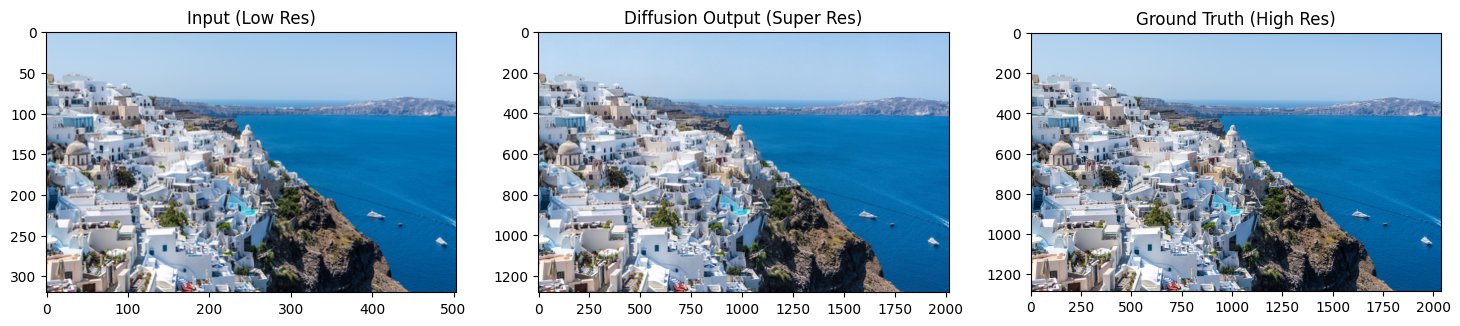

In [26]:
if __name__ == "__main__":
    trained_model, betas, alphas, alphas_cumprod = train_model()
    run_inference(trained_model, betas, alphas, alphas_cumprod)